In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load data
file_path = r'D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-10-18_listings.csv.gz'
listings = pd.read_csv(file_path, compression='gzip')

cols_to_clean = [
    'number_of_reviews', 'price', 'reviews_per_month', 'room_type', 'accommodates', 
    'availability_30', 'bathrooms_text', 'bedrooms', 'beds', 'property_type', 
    'host_since', 'maximum_nights', 'minimum_nights', 'host_response_time', 
    'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 
    'calculated_host_listings_count', 'host_is_superhost', 'host_identity_verified', 
    'host_has_profile_pic', 'has_availability', 'instant_bookable', 'amenities',
]

missing_summary = pd.DataFrame({
    'Missing count': listings[cols_to_clean].isna().sum(),
    'Missing percentage (%)': (listings[cols_to_clean].isna().sum() / len(listings) * 100).round(2)
})
print(missing_summary)

df = listings[cols_to_clean].copy()


                                Missing count  Missing percentage (%)
number_of_reviews                           0                    0.00
price                                     946                   16.81
reviews_per_month                         413                    7.34
room_type                                   0                    0.00
accommodates                                0                    0.00
availability_30                             0                    0.00
bathrooms_text                              7                    0.12
bedrooms                                  243                    4.32
beds                                      958                   17.02
property_type                               0                    0.00
host_since                                  0                    0.00
maximum_nights                              0                    0.00
minimum_nights                              0                    0.00
host_response_time  

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5629 entries, 0 to 5628
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   number_of_reviews               5629 non-null   int64  
 1   price                           4683 non-null   str    
 2   reviews_per_month               5216 non-null   float64
 3   room_type                       5629 non-null   str    
 4   accommodates                    5629 non-null   int64  
 5   availability_30                 5629 non-null   int64  
 6   bathrooms_text                  5622 non-null   str    
 7   bedrooms                        5386 non-null   float64
 8   beds                            4671 non-null   float64
 9   property_type                   5629 non-null   str    
 10  host_since                      5629 non-null   str    
 11  maximum_nights                  5629 non-null   int64  
 12  minimum_nights                  5629 non-null

In [ ]:
original_count = len(df)
# Price
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
missing_price_count = df['price'].isnull().sum()
print(f" Missing Value {missing_price_count} ")

 Missing Value 946 


In [ ]:
# 1. Strip the target variable and preliminarily clean up the missing value of Price
df = df.dropna(subset=['price'])

y = df['price'].copy()
X = df.drop(columns=['price']).copy()

# 2. Cleaning Boolean values
bool_cols = ['host_is_superhost', 'host_identity_verified', 'host_has_profile_pic', 
             'has_availability', 'instant_bookable']
for col in bool_cols:
    X[col] = X[col].map({'t': 1.0, 'f': 0.0})

# 3. Cleaning percentage
for col in ['host_response_rate', 'host_acceptance_rate']:
    X[col] = X[col].astype(str).str.replace('%', '', regex=False)
    X[col] = pd.to_numeric(X[col], errors='coerce') / 100.0

# 4.  Extract the number of bathrooms
X['bathrooms'] = X['bathrooms_text'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# 5. Calculate the number of days the landlord has registered
scrape_date = pd.to_datetime('2024-10-18')
X['host_since'] = pd.to_datetime(X['host_since'], errors='coerce')
X['host_days'] = (scrape_date - X['host_since']).dt.days

# 6. Classification variable mapping
X['room_type_code'] = X['room_type'].map({'Private room': 1, 'Entire home/apt': 2, 'Shared room': 3, 'Hotel room': 4})
X['host_response_time_code'] = X['host_response_time'].str.lower().map(
    {'within an hour': 1, 'within a few hours': 2, 'within a day': 3, 'a few days or more': 4}
)

# 7. Amenities
X['amenities'] = X['amenities'].fillna('')

cleaned_amenities = X['amenities'].astype(str).str.replace(r'[{}"\'\[\]]', '', regex=True).str.lower()

X['amenity_tv'] = cleaned_amenities.str.contains('tv').astype(float)
X['amenity_air_conditioning'] = cleaned_amenities.str.contains('air conditioning|ac').astype(float)
X['amenity_coffee'] = cleaned_amenities.str.contains('coffee').astype(float)
X['amenity_luggage'] = cleaned_amenities.str.contains('luggage').astype(float)

X = X.drop(columns=['bathrooms_text', 'room_type', 'host_response_time', 'property_type', 'host_since', 'amenities'])

In [ ]:
# Dataset segmentation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_original = X_train.copy()

In [ ]:
def type_sort(data):
    """ Sorts a dataframe by variable type and counts feature classes """
    binary = [i for i in data.columns if len(data[i].dropna().unique()) <= 2]
    multi = [k for k in data.columns if data[k].dtype == 'category']
    quant = [j for j in data.columns if j not in binary and j not in multi]
    variables = quant + binary + multi
    X = pd.DataFrame(data.loc[:, variables])
    (p1, p2, p3) = (len(quant), len(binary), len(multi))
    return (X, p1, p2, p3)

def vgeom(D):
    """ Computes Geometric Variability """
    n = D.shape[0]
    suma = np.sum(D, axis=1)
    return np.sum(suma) / 2 * n ** 2

def gower_safe(X1, X2, X3):
    """ Safe Gower distance that avoids singular matrices. """
    if X1.shape[1] > 0:
        cov = np.cov(X1.T, bias=False)
        cov = np.atleast_2d(cov) 
        cov += np.eye(cov.shape[0]) * 1e-08
        S_inv = np.linalg.inv(cov)
        M = pairwise_distances(X1, metric='mahalanobis', VI=S_inv)
        M2 = M ** 2
        M /= vgeom(M2)
    else:
        M = 0
    if X2.shape[1] > 0:
        J = cdist(X2, X2, metric='jaccard')
        J2 = J ** 2
        J /= vgeom(J2)
    else:
        J = 0
    if X3.shape[1] > 0:
        C = cdist(X3, X3, metric='hamming')
        C2 = C ** 2
        C /= vgeom(C2)
    else:
        C = 0
    return M + J + C

# Core KNN Interpolator

def KNN_Imputer(feature, target, k):
    """ Robust KNN imputer using Gower distance """
    feature = feature.copy()

    original_index = feature.index 
    feature = feature.reset_index(drop=True) 
    
    num_cols = feature.select_dtypes(include=[np.number]).columns
    non_num_cols = feature.columns.difference(num_cols)
    X = feature[num_cols].copy()
    
    missing_cols = [col for col in X.columns if X[col].isna().sum() > 0]
    if len(missing_cols) == 0:
        feature.index = original_index
        return feature
        
    distance_data = X.drop(columns=missing_cols)
    (distance_data, p1, p2, p3) = type_sort(distance_data)
    p = p1 + p2 + p3
    X1 = distance_data.iloc[:, :p1]
    X2 = distance_data.iloc[:, p1:p1 + p2]
    X3 = distance_data.iloc[:, p1 + p2:p]
    
    if p1 > 0:
        non_constant = X1.columns[X1.var() > 0]
        X1 = X1[non_constant]
        
    D = gower_safe(X1, X2, X3)
    D = D + np.eye(D.shape[0]) * D.max()
    k_neighbors = np.argpartition(D, kth=k, axis=1)[:, :k]
    
    for col in missing_cols:
        missing_idx = X[col].isna()
        for row in np.where(missing_idx)[0]:
            neighbors = k_neighbors[row]
            X.loc[row, col] = np.nanmean(X.loc[neighbors, col])
            
    if X.isna().any().any():
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=42)
        X[num_cols] = imp.fit_transform(X)
        
    X_final = pd.concat([X, feature[non_num_cols]], axis=1)
    X_final = X_final[feature.columns]

    X_final.index = original_index 
    
    return X_final

In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist

categorical_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 
                    'has_availability', 'instant_bookable', 'room_type_code', 'host_response_time_code']
discrete_cols = ['bedrooms', 'bathrooms', 'beds']

X_train_cat_imputed = KNN_Imputer(feature=X_train[categorical_cols], target=y_train, k=5)
X_train[categorical_cols] = X_train_cat_imputed
X_test_cat_imputed = KNN_Imputer(feature=X_test[categorical_cols], target=y_test, k=5)
X_test[categorical_cols] = X_test_cat_imputed

# Bayesian Ridge
iterative_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=42, min_value=0)
iterative_imputer.fit(X_train) 

X_train_imputed = pd.DataFrame(iterative_imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed  = pd.DataFrame(iterative_imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

for col in discrete_cols:
    X_train_imputed[col] = np.round(X_train_imputed[col])
    X_test_imputed[col] = np.round(X_test_imputed[col])

print(f"Residual missing values in the training set: {X_train_imputed.isnull().sum().max()}")

Residual missing values in the training set: 0


In [ ]:
print(f"Total number of missing values in test set: {X_test.isnull().sum().sum()}")
print(f"Missing values after interpolation : {X_test_imputed.isnull().sum().sum()}")
print(f"Test: {X_test_imputed.shape}")

Total number of missing values in test set: 159
Missing values after interpolation : 0
Test: (937, 25)


amenity_tv                  0.797
amenity_air_conditioning    0.755
amenity_coffee              0.561
amenity_luggage             0.238
dtype: float64


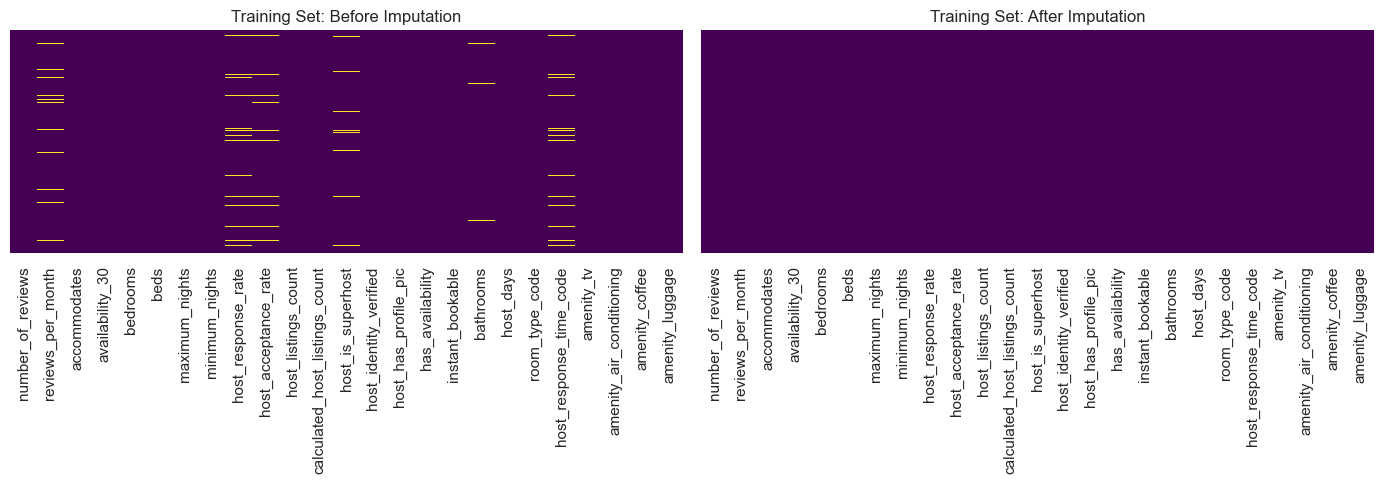

In [ ]:
sns.set_theme(style="whitegrid")

amenity_cols = ['amenity_tv', 'amenity_air_conditioning', 'amenity_coffee', 'amenity_luggage']
print(X_train_imputed[amenity_cols].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(X_train_original.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Training Set: Before Imputation")

sns.heatmap(X_train_imputed.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title("Training Set: After Imputation")
plt.tight_layout()
plt.show()

X_train_imputed : 3746 行, 25 列
X_test_imputed : 937 行, 25 列
--------------------------------------------------
                         Before Imputation  After Imputation
reviews_per_month                      250                 0
bedrooms                                 3                 0
beds                                    16                 0
host_response_rate                     166                 0
host_acceptance_rate                   117                 0
host_is_superhost                       75                 0
has_availability                        12                 0
bathrooms                               33                 0
host_response_time_code                166                 0
--------------------------------------------------


<Figure size 1200x600 with 0 Axes>

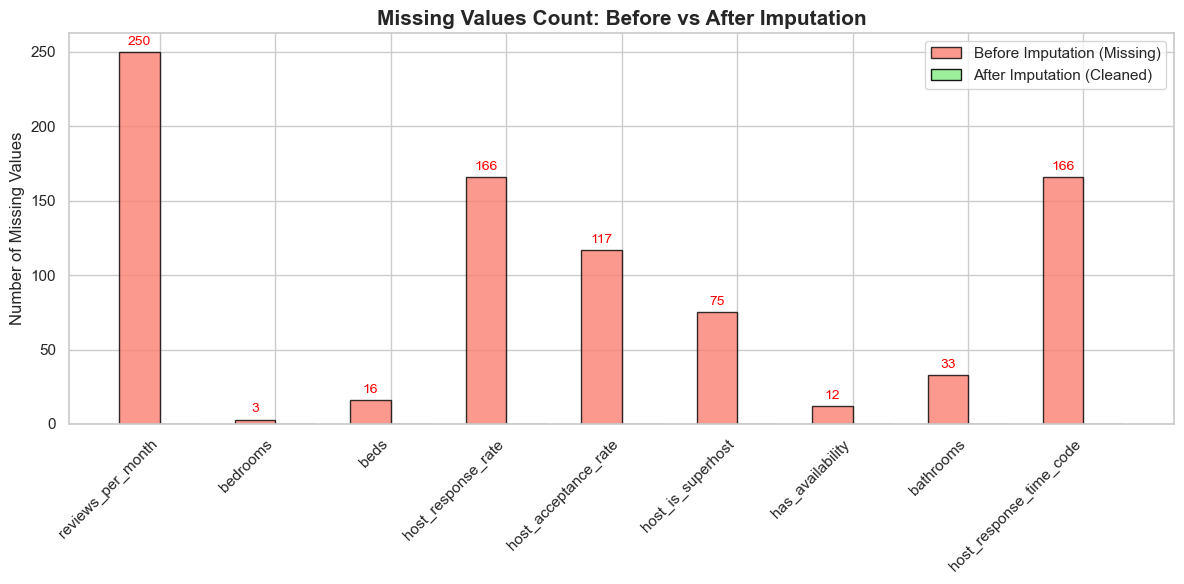

In [ ]:
print(f"X_train_imputed : {X_train_imputed.shape[0]} 行, {X_train_imputed.shape[1]} 列")
print(f"X_test_imputed : {X_test_imputed.shape[0]} 行, {X_test_imputed.shape[1]} 列")
print("-" * 50)

missing_before = X_train_original.isnull().sum()
missing_after = X_train_imputed.isnull().sum()

cols_with_missing = missing_before[missing_before > 0].index

comparison_df = pd.DataFrame({
    'Before Imputation': missing_before[cols_with_missing],
    'After Imputation': missing_after[cols_with_missing]
})

print(comparison_df)
print("-" * 50)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

x_labels = comparison_df.index
x = range(len(x_labels))
width = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar([i - width/2 for i in x], comparison_df['Before Imputation'], width, 
                label='Before Imputation (Missing)', color='salmon', edgecolor='black', alpha=0.8)
rects2 = ax.bar([i + width/2 for i in x], comparison_df['After Imputation'], width, 
                label='After Imputation (Cleaned)', color='lightgreen', edgecolor='black', alpha=0.9)

ax.set_ylabel('Number of Missing Values', fontsize=12)
ax.set_title('Missing Values Count: Before vs After Imputation', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=11)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{int(height)}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color='red')

plt.tight_layout()
plt.show()

In [ ]:
train_full = pd.concat([X_train, y_train], axis=1)
train_full['dataset_split'] = 'train' 

test_full = pd.concat([X_test, y_test], axis=1)
test_full['dataset_split'] = 'test'

df_imputed_final = pd.concat([train_full, test_full])

In [ ]:
# Exclude extreme values, take logarithms&export

q99_price = df_imputed_final['price'].quantile(0.99)
df_imputed_final = df_imputed_final[df_imputed_final['price'] <= q99_price]

df_imputed_final = df_imputed_final[df_imputed_final['price'] > 0]

df_imputed_final['log_price'] = np.log(df_imputed_final['price'])

In [ ]:
# 4. 导出为 CSV 文件
output_path = r'D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-10-18_listings_priceCLEANED_dropNan.csv'
df_imputed_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Final output dataset: {df_imputed_final.shape}")

最终输出的数据表大小: (4646, 28)


=== 最终清洗并插补后的数据全貌 ===
1. 总有效样本量: 4646 个房源
2. 价格统计摘要 (Price Summary):
count    4646.00
mean      182.33
std       141.40
min        18.00
25%       100.00
50%       146.00
75%       211.75
max      1000.00
Name: price, dtype: float64


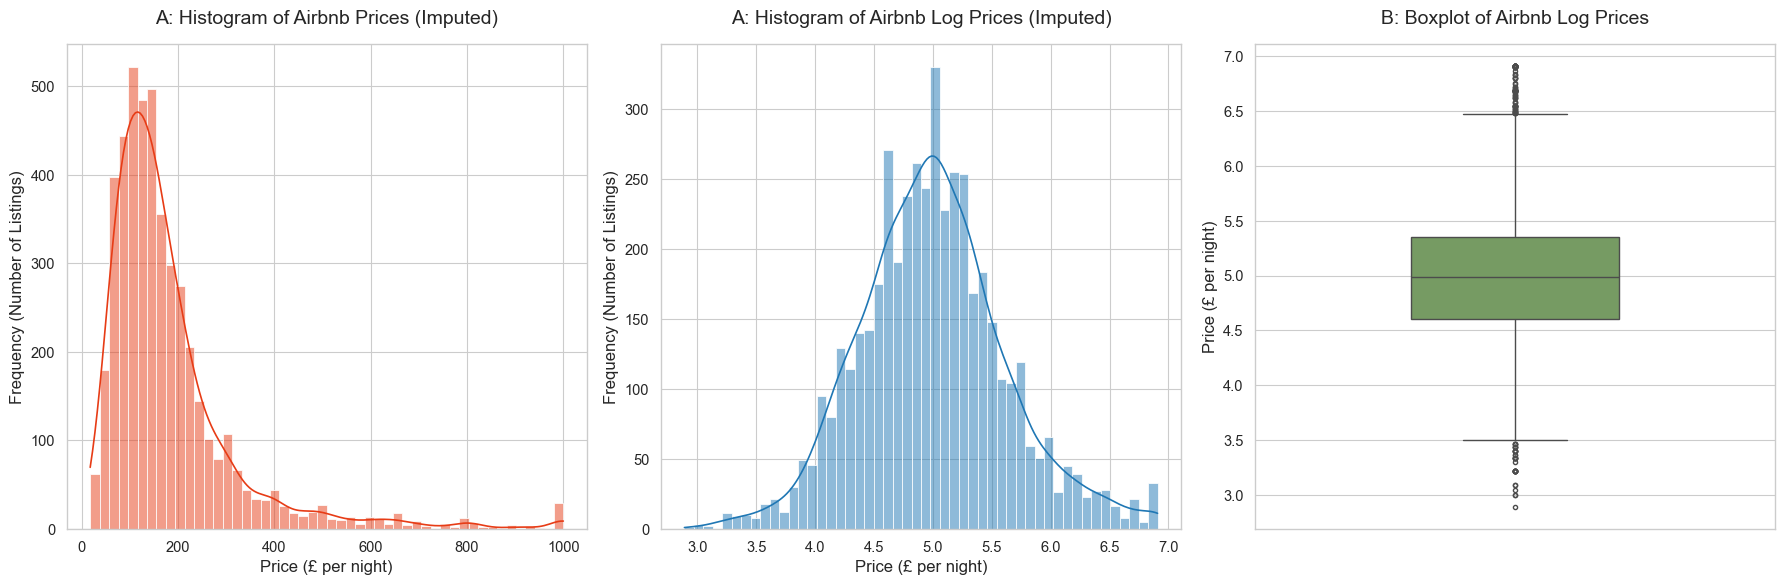

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

total_samples = len(df_imputed_final)
print(f"=== 最终清洗并插补后的数据全貌 ===")
print(f"1. 总有效样本量: {total_samples} 个房源")
print(f"2. 价格统计摘要 (Price Summary):")
print(df_imputed_final['price'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(
    df_imputed_final['price'], 
    bins=50,
    kde=True,
    color="#e73c16",
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_title('A: Histogram of Airbnb Prices (Imputed)', fontsize=14, pad=15)
axes[0].set_xlabel('Price (£ per night)', fontsize=12)
axes[0].set_ylabel('Frequency (Number of Listings)', fontsize=12)

sns.histplot(
    df_imputed_final['log_price'], 
    bins=50,
    kde=True,
    color='#1f77b4',
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title('A: Histogram of Airbnb Log Prices (Imputed)', fontsize=14, pad=15)
axes[1].set_xlabel('Price (£ per night)', fontsize=12)
axes[1].set_ylabel('Frequency (Number of Listings)', fontsize=12)

sns.boxplot(
    y=df_imputed_final['log_price'], 
    color="#73a45a", 
    width=0.4,
    fliersize=3,
    ax=axes[2]
)
axes[2].set_title('B: Boxplot of Airbnb Log Prices', fontsize=14, pad=15)
axes[2].set_ylabel('Price (£ per night)', fontsize=12)

plt.tight_layout()

plt.savefig(r'D:\PythonProjects\Airbnb-Performace\price_distribution_dropNan.png', dpi=300, bbox_inches='tight')

plt.show()

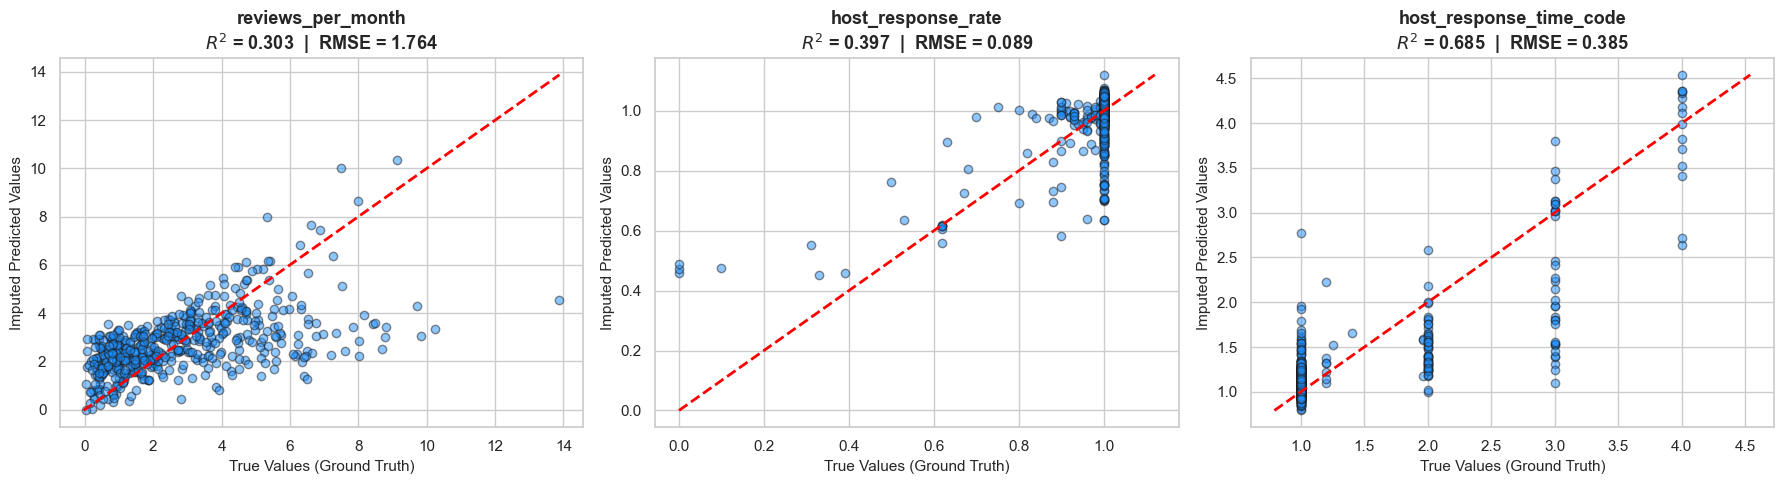

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

features_to_evaluate = ['reviews_per_month', 'host_response_rate', 'host_response_time_code']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

for i, target_col in enumerate(features_to_evaluate):

    complete_data = X_train.dropna(subset=[target_col]).copy()

    np.random.seed(42)
    mask_ratio = 0.15
    n_missing = int(len(complete_data) * mask_ratio)
    missing_indices = np.random.choice(complete_data.index, size=n_missing, replace=False)
    
    true_values = complete_data.loc[missing_indices, target_col].copy()
    
    corrupted_data = complete_data.copy()
    corrupted_data.loc[missing_indices, target_col] = np.nan

    num_cols = corrupted_data.select_dtypes(include=[np.number]).columns
    X_test_impute = corrupted_data[num_cols].copy()
    
    imputer_eval = IterativeImputer(estimator=BayesianRidge(), max_iter=15, random_state=42)
    X_test_imputed_array = imputer_eval.fit_transform(X_test_impute)
    X_test_imputed_df = pd.DataFrame(X_test_imputed_array, columns=X_test_impute.columns, index=X_test_impute.index)
    
    imputed_values = X_test_imputed_df.loc[missing_indices, target_col]

    r2 = r2_score(true_values, imputed_values)
    mae = mean_absolute_error(true_values, imputed_values)
    rmse = np.sqrt(mean_squared_error(true_values, imputed_values))

    ax = axes[i]
    ax.scatter(true_values, imputed_values, alpha=0.5, color='dodgerblue', edgecolor='k')

    min_val = min(true_values.min(), imputed_values.min())
    max_val = max(true_values.max(), imputed_values.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    ax.set_title(f'{target_col}\n$R^2$ = {r2:.3f}  |  RMSE = {rmse:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('True Values (Ground Truth)', fontsize=11)
    ax.set_ylabel('Imputed Predicted Values', fontsize=11)

plt.tight_layout()
plt.show()

plt.savefig(r'D:\PythonProjects\Airbnb-Performace\residuals_dropNan.png', dpi=300, bbox_inches='tight')